In [1]:
filt_conds = dict(
    Ms_min = 2e10,          # M_sol
    Ms_max = 5e11,          # M_sol
    r_min = 500,            # kpc
    r_max = 1000,           # kpc
    vt_min = 0,             # km/s
    vt_max = 300,           # km/s
    vr_min= -400,           # km/s
    vr_max = 0,             # km/s
    third_massive_m = 1.0,  # factor
    intruder_r = 1500,      # kpc
    intruder_m = 0.5        # factor
)

filts = dict()

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il

from lg_analogues import (
    load_header_constants,
    select_central_plus_largest_satellite_by_stellar_mass,
    find_pairs_periodic,
    isolation_filter_no_third_factor_x_in_same_group,
    isolation_filter_no_massive_intruder_within_distance_x,
    calculate_force_ratio,
    compute_tidal_dominance
)

basePath = os.path.expanduser("~/Documents/uni/dsp/tng300/outputs")
snap = 99

In [3]:
# Load header constants
const = load_header_constants(basePath, snap)
h = const["h"]
box_ckpch = const["box_ckpch"]

print("h:", h)
print("BoxSize [ckpc/h]:", box_ckpch)

h: 0.6774
BoxSize [ckpc/h]: 205000.0


In [4]:
# Load subhalo fields needed for selection, pair finding, and photometry
subhalo_fields = [ 
    "SubhaloPos",
    "SubhaloVel",
    "SubhaloMass",
    "SubhaloMassType",
    "SubhaloSFRinRad",
    "SubhaloFlag",
    "SubhaloGrNr",
    "SubhaloStellarPhotometrics",
    "SubhaloSFR",
    "SubhaloMassInRadType"
]

sub = il.groupcat.loadSubhalos(basePath, snap, fields=subhalo_fields)
print("All subhalos:", sub["count"])

All subhalos: 14485709


In [5]:
# Selection: centrals with stellar mass in window, plus largest satellite in window (per FoF group)
sample = select_central_plus_largest_satellite_by_stellar_mass(
    sub=sub,
    basePath=basePath,
    snap=snap,
    h=h,
    mstar_min=filt_conds["Ms_min"],
    mstar_max=filt_conds["Ms_max"],
)

print("Sample size:", sample.pos.shape[0])
print(f"Stellar mass range: [{float(sample.mstar.min()):.3e}, {float(sample.mstar.max()):.3e}] M_sol")
print("Groups represented:", np.unique(sample.grnr).size)
print("Centrals:", sample.is_central.sum())
print("Satellites:", (~sample.is_central).sum())

Sample size: 45392
Stellar mass range: [2.000e+10, 4.999e+11] M_sol
Groups represented: 38778
Centrals: 38778
Satellites: 6614


In [6]:
# Pair finding (periodic), 500-1000 kpc
pairs = find_pairs_periodic(
    pos=sample.pos,
    vel=sample.vel,
    grnr=sample.grnr,
    h=h,
    box_ckpch=box_ckpch,
    r_min_kpc=filt_conds["r_min"],
    r_max_kpc=filt_conds["r_max"],
)

print("Pairs found:", pairs.i.size)
print(f"  Same-host pairs: {pairs.same_host.sum()}")
print(f"  Different-host pairs: {(~pairs.same_host).sum()}")
print(f"Separation stats [kpc]: min/median/max = {pairs.dist_kpc.min():.1f}, {np.median(pairs.dist_kpc):.1f}, {pairs.dist_kpc.max():.1f}")
print(f"v_r stats [km/s]: min/median/max = {pairs.v_r.min():.1f}, {np.median(pairs.v_r):.1f}, {pairs.v_r.max():.1f}")
print(f"v_t stats [km/s]: min/median/max = {pairs.v_t.min():.1f}, {np.median(pairs.v_t):.1f}, {pairs.v_t.max():.1f}")

Pairs found: 2655
  Same-host pairs: 2084
  Different-host pairs: 571
Separation stats [kpc]: min/median/max = 500.4, 740.6, 1000.0
v_r stats [km/s]: min/median/max = -1282.9, -123.8, 748.4
v_t stats [km/s]: min/median/max = 3.0, 155.0, 1626.1


In [7]:
# Isolation filter: no third subhalo in same FoF group(s) >= x times more massive
# than the larger pair member
mask_group = isolation_filter_no_third_factor_x_in_same_group(
    sub=sub,
    pair_i=pairs.i,
    pair_j=pairs.j,
    sample_grnr=sample.grnr,
    sample_keep_idx_global=sample.keep_idx,
    h=h,
    x=filt_conds["third_massive_m"],
)

print(f"Pairs after group isolation: {mask_group.sum()}")

Pairs after group isolation: 2571


In [8]:
# Isolation filter: no massive intruder within r_iso_kpc of the pair center of mass
mask_spatial = isolation_filter_no_massive_intruder_within_distance_x(
    sub=sub,
    pair_i=pairs.i,
    pair_j=pairs.j,
    sample_pos=sample.pos,
    sample_keep_idx_global=sample.keep_idx,
    h=h,
    box_ckpch=box_ckpch,
    r_iso_kpc=filt_conds["intruder_r"],
    mass_factor=filt_conds["intruder_m"]
)

# Combine both isolation filters
keep_iso = mask_group & mask_spatial
print(f"Pairs surviving both isolation conditions: {keep_iso.sum()}")

Pairs surviving both isolation conditions: 2571


In [9]:
# Velocity cuts
keep_vel = (
    (pairs.v_t >= filt_conds["vt_min"])
    & (pairs.v_t <= filt_conds["vt_max"])
    & (pairs.v_r >= filt_conds["vr_min"])
    & (pairs.v_r <= filt_conds["vr_max"])
)

print(f"Isolated pairs surviving velocity conditions: {np.sum(keep_vel & keep_iso)}")

Isolated pairs surviving velocity conditions: 1743


In [10]:
# Force ratio: ratio of external to internal gravitational force for each pair
f_ratios = calculate_force_ratio(sub, pairs, sample, h, box_ckpch, 
                                  search_radius_kpc=filt_conds["intruder_r"])

print(f"Range of force ratios: [{f_ratios.min():.3f}, {f_ratios.max():.3f}]")

internally_dom = f_ratios < 0.5
print(f"Internally dominated isolated pairs: {np.sum(keep_iso & internally_dom)}")

Range of force ratios: [0.035, 5197.234]
Internally dominated isolated pairs: 488


In [11]:
# Tidal dominance: pairs where mutual gravity dominates over external tidal forces
tidally_dom = compute_tidal_dominance(sub, pairs, sample, h, box_ckpch, 
                                       search_radius_kpc=filt_conds["intruder_r"])

print(f"Tidally dominant isolated pairs: {np.sum(keep_iso & tidally_dom)}")

Tidally dominant isolated pairs: 952


In [12]:
# Load photometry and SFR for the selected sample
phot_s = sub["SubhaloStellarPhotometrics"][sample.keep_idx]
sfr_s = sub["SubhaloSFR"][sample.keep_idx]

# Apply combined filter (isolation + velocity)
keep = keep_iso & keep_vel

# Pair indices after all filters
i_final = pairs.i[keep]
j_final = pairs.j[keep]

# Kinematics after all filters
v_r_final = pairs.v_r[keep]
v_t_final = pairs.v_t[keep]
dist_kpc_final = pairs.dist_kpc[keep]

# Stellar masses
Mi_star = sample.mstar[i_final]
Mj_star = sample.mstar[j_final]

# g-r colors for each pair member
g_r_1 = phot_s[i_final, 4] - phot_s[i_final, 5]
g_r_2 = phot_s[j_final, 4] - phot_s[j_final, 5]

# Color-based pair classification
blue_blue = (g_r_1 < 0.65) & (g_r_2 < 0.65)
red_red = (g_r_1 >= 0.65) & (g_r_2 >= 0.65)

print(f"Total pairs after all filters: {keep.sum()}")
print(f"Blue-blue pairs: {blue_blue.sum()}")
print(f"Red-red pairs: {red_red.sum()}")
print(f"Mixed pairs: {(~blue_blue & ~red_red).sum()}")

Total pairs after all filters: 1743
Blue-blue pairs: 160
Red-red pairs: 904
Mixed pairs: 679


C:\Users\Muhammad Abeer\AppData\Local\Temp\ipykernel_2496\3834408604.py:85: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


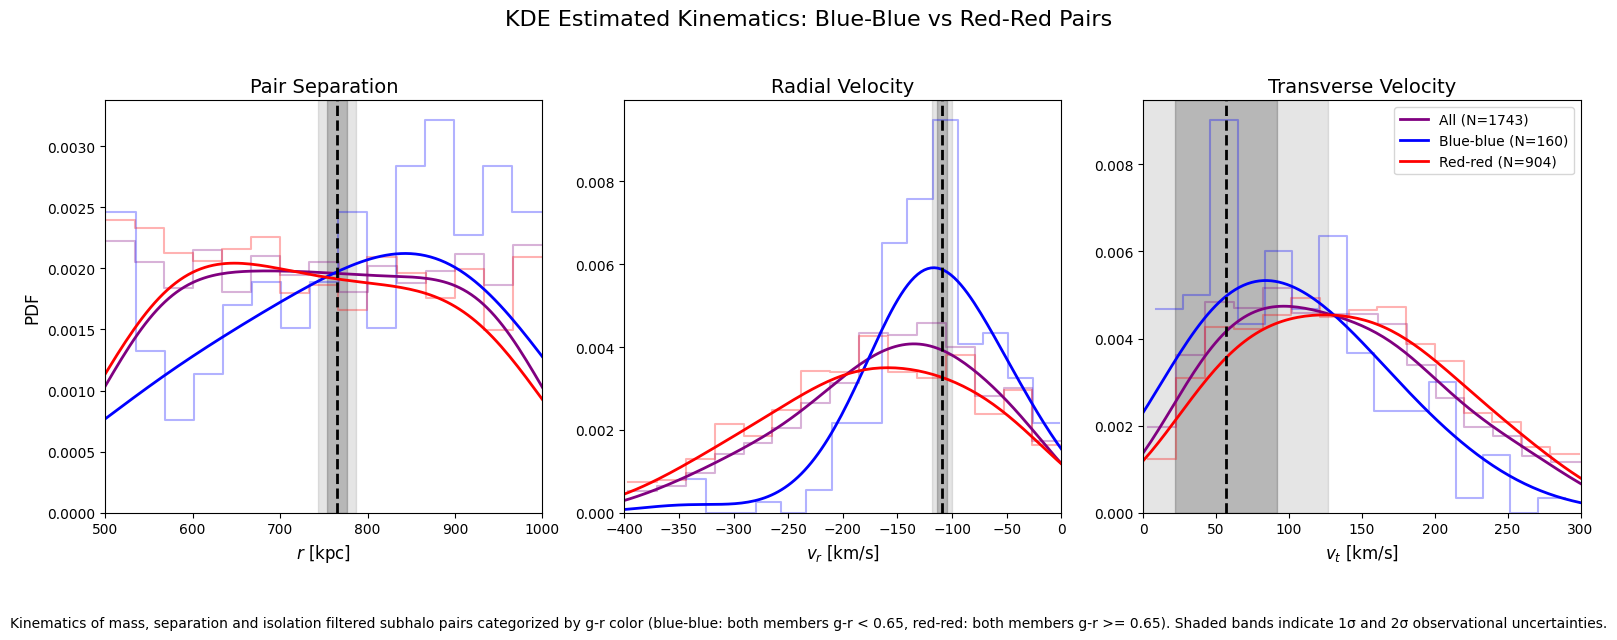

In [ ]:
# KDE plots with separation and radial velocity by color type
import seaborn as sns

# Data for each color type
dist_bb = dist_kpc_final[blue_blue]
dist_rr = dist_kpc_final[red_red]
vr_bb = v_r_final[blue_blue]
vr_rr = v_r_final[red_red]
vt_bb = v_t_final[blue_blue]
vt_rr = v_t_final[red_red]

obs_data = {
    'r':  {'val': 765, 'sigma': 11},
    'vr': {'val': -109.3, 'sigma': 4.4},
    'vt': {'val': 57, 'sigma': 35}
}

bw = 2

fig, axes = plt.subplots(1, 3, figsize=(16, 6), constrained_layout=True)

ranges = {
    'r':  [filt_conds["r_min"], filt_conds["r_max"]],
    'vr': [filt_conds["vr_min"], filt_conds["vr_max"]],
    'vt': [filt_conds["vt_min"], filt_conds["vt_max"]]
}

titles = ["Pair Separation", "Radial Velocity", "Transverse Velocity"]
x_labels = ["$r$ [kpc]", "$v_r$ [km/s]", "$v_t$ [km/s]"]

data_all = [dist_kpc_final, v_r_final, v_t_final]
data_bb = [dist_bb, vr_bb, vt_bb]
data_rr = [dist_rr, vr_rr, vt_rr]
obs_keys = ['r', 'vr', 'vt']

N_all = len(dist_kpc_final)
N_bb = len(dist_bb)
N_rr = len(dist_rr)

for i, key in enumerate(obs_keys):
    # Underlying histograms
    sns.histplot(data_all[i], ax=axes[i], color='purple', element='step',
                 fill=False, stat='density', alpha=0.3, bins=15)
    sns.histplot(data_bb[i], ax=axes[i], color='blue', element='step',
                 fill=False, stat='density', alpha=0.3, linewidth=1.5, bins=15)
    sns.histplot(data_rr[i], ax=axes[i], color='red', element='step',
                 fill=False, stat='density', alpha=0.3, linewidth=1.5, bins=15)

    # KDE curves
    sns.kdeplot(data_all[i], ax=axes[i], color='purple', linestyle='-',
                linewidth=2, label=f'All (N={N_all})', bw_adjust=bw)
    sns.kdeplot(data_bb[i], ax=axes[i], color='blue', linestyle='-',
                linewidth=2, label=f'Blue-blue (N={N_bb})', bw_adjust=bw)
    sns.kdeplot(data_rr[i], ax=axes[i], color='red', linestyle='-',
                linewidth=2, label=f'Red-red (N={N_rr})', bw_adjust=bw)

    # Set x limits
    axes[i].set_xlim(ranges[key])

    # Observational uncertainty regions
    mu = obs_data[key]['val']
    std = obs_data[key]['sigma']
    axes[i].axvspan(mu - 2*std, mu + 2*std, color='black', alpha=0.1)
    axes[i].axvspan(mu - std, mu + std, color='black', alpha=0.2)
    axes[i].axvline(mu, color='black', linestyle='--', linewidth=2)

    axes[i].set_title(titles[i], fontsize=14)
    axes[i].set_xlabel(x_labels[i], fontsize=12)
    axes[i].set_ylabel("")

axes[0].set_ylabel("PDF", fontsize=12)
axes[2].legend()

plt.suptitle("KDE Estimated Kinematics: Blue-Blue vs Red-Red Pairs", fontsize=16, y=0.98)

caption = " ".join([
    "Kinematics of mass, separation and isolation filtered subhalo pairs",
    "categorized by g-r color (blue-blue: both members g-r < 0.65,",
    "red-red: both members g-r >= 0.65).",
    "Shaded bands indicate 1σ and 2σ observational uncertainties."
])

plt.figtext(0.5, -0.05, caption, wrap=True, horizontalalignment='center', fontsize=10)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

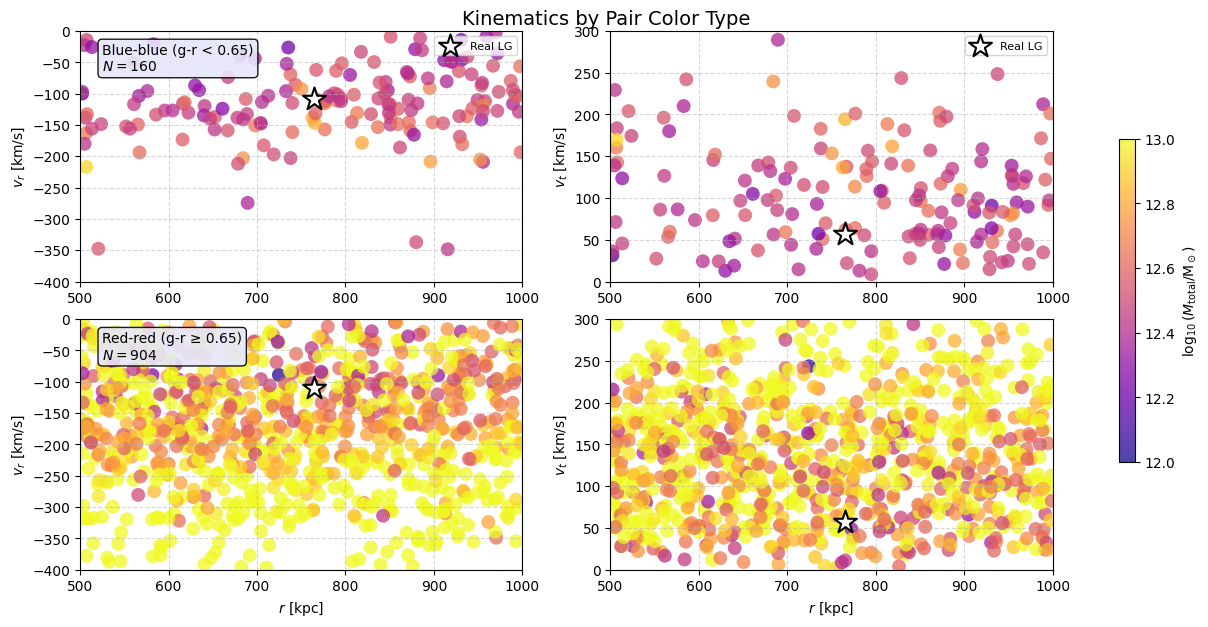

In [ ]:
# Scatter plots separation vs v_r and v_t coloured by total pair mass

def build_kinematics_plots(masks, legs, title):
    fig, axes = plt.subplots(2, 2, figsize=(12, 6), constrained_layout=True)
    cmap = plt.get_cmap('plasma')

    for row, (mask, leg) in enumerate(zip(masks, legs)):
        idx_i = pairs.i[keep][mask]
        idx_j = pairs.j[keep][mask]
        r = dist_kpc_final[mask]
        vr = v_r_final[mask]
        vt = v_t_final[mask]

        m_i = sample.mtot[idx_i]
        m_j = sample.mtot[idx_j]
        m_total_log = np.log10(m_i + m_j)

        # Separation vs Radial Velocity
        sc_vr = axes[row, 0].scatter(r, vr, c=m_total_log, s=100, alpha=0.75,
                                      cmap=cmap, edgecolors='none', vmin=12.0, vmax=13.0)
        axes[row, 0].set_ylabel(r'$v_r$ [km/s]')
        axes[row, 0].set_xlim(filt_conds["r_min"], filt_conds["r_max"])
        axes[row, 0].set_ylim(filt_conds["vr_min"], filt_conds["vr_max"])
        axes[row, 0].grid(True, linestyle='--', alpha=0.5)

        # Separation vs Transverse Velocity
        sc_vt = axes[row, 1].scatter(r, vt, c=m_total_log, s=100, alpha=0.75,
                                      cmap=cmap, edgecolors='none', vmin=12.0, vmax=13.0)
        axes[row, 1].set_ylabel(r'$v_t$ [km/s]')
        axes[row, 1].set_xlim(filt_conds["r_min"], filt_conds["r_max"])
        axes[row, 1].set_ylim(filt_conds["vt_min"], filt_conds["vt_max"])
        axes[row, 1].grid(True, linestyle='--', alpha=0.5)

        # Real LG reference point
        axes[row, 0].scatter(765, -109.3, marker='*', s=300, color='white',
                             edgecolor='black', linewidth=1.5, label='Real LG', zorder=10)
        axes[row, 1].scatter(765, 57, marker='*', s=300, color='white',
                             edgecolor='black', linewidth=1.5, label='Real LG', zorder=10)

        # Row label
        axes[row, 0].text(0.05, 0.95, f"{leg}\n$N = {len(r)}$",
                          transform=axes[row, 0].transAxes, verticalalignment='top',
                          bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.9))

    for col in range(2):
        axes[1, col].set_xlabel(r'$r$ [kpc]')
        axes[0, col].legend(loc='upper right', fontsize=8)

    cb = fig.colorbar(sc_vt, ax=axes, location='right',
                      label=r'$\log_{10}(M_{\mathrm{total}} / \mathrm{M}_\odot)$', shrink=0.6)

    plt.suptitle(title, fontsize=14, y=1.02)
    plt.show()

# Define masks and labels for color-based classification
color_masks = [blue_blue, red_red]
color_legs = ["Blue-blue (g-r < 0.65)", "Red-red (g-r ≥ 0.65)"]

build_kinematics_plots(color_masks, color_legs, "Kinematics by Pair Color Type")

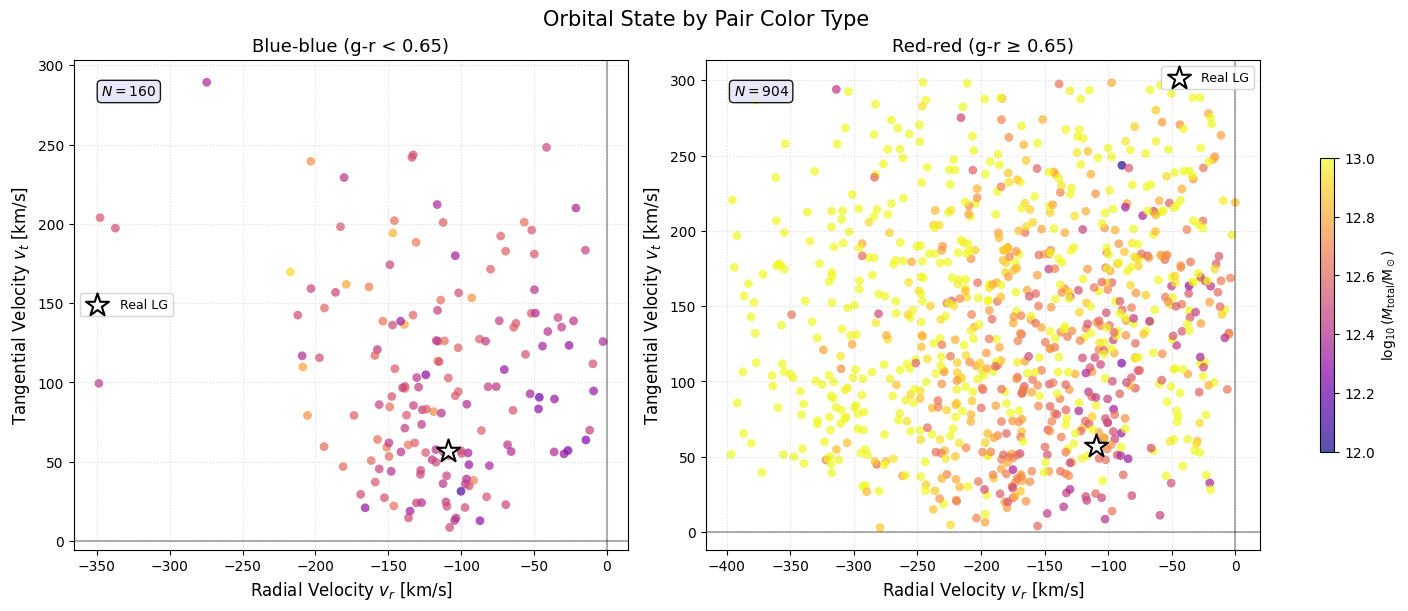

In [15]:
# Orbital state: v_r vs v_t coloured by total pair mass
def plot_orbital_state(masks, legs, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
    cmap = plt.get_cmap('plasma')

    for col, (mask, leg) in enumerate(zip(masks, legs)):
        idx_i = pairs.i[keep][mask]
        idx_j = pairs.j[keep][mask]
        vr = v_r_final[mask]
        vt = v_t_final[mask]

        m_i = sample.mtot[idx_i]
        m_j = sample.mtot[idx_j]
        m_total_log = np.log10(m_i + m_j)

        sc = axes[col].scatter(vr, vt, c=m_total_log, s=40, alpha=0.7,
                               cmap=cmap, vmin=12.0, vmax=13.0, edgecolors='none')

        # Real LG reference
        axes[col].scatter(-109.3, 57, color='white', marker='*', s=300,
                          edgecolor='black', linewidth=1.5, label='Real LG', zorder=10)

        axes[col].set_xlabel(r'Radial Velocity $v_r$ [km/s]', fontsize=12)
        axes[col].set_ylabel(r'Tangential Velocity $v_t$ [km/s]', fontsize=12)
        axes[col].set_title(leg, fontsize=13)
        axes[col].axhline(0, color='black', alpha=0.3)
        axes[col].axvline(0, color='black', alpha=0.3)
        axes[col].grid(True, linestyle=':', alpha=0.4)
        axes[col].legend(fontsize=9)

        axes[col].text(0.05, 0.95, f"$N = {len(vr)}$",
                       transform=axes[col].transAxes, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.9))

    cb = fig.colorbar(sc, ax=axes, location='right',
                      label=r'$\log_{10}(M_{\mathrm{total}} / \mathrm{M}_\odot)$', shrink=0.6)

    plt.suptitle(title, fontsize=15)
    plt.show()

plot_orbital_state(color_masks, color_legs, "Orbital State by Pair Color Type")

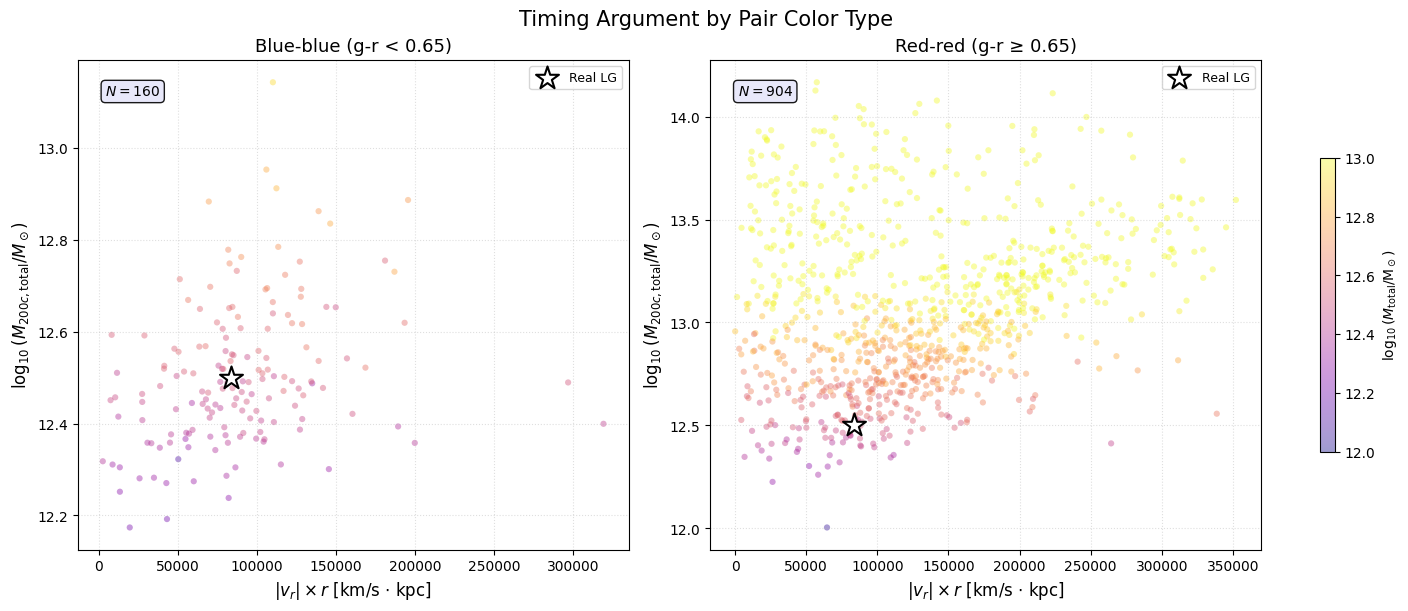

In [16]:
# Timing argument: |v_r| x r vs total halo mass
def plot_timing_argument(masks, legs, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
    cmap = plt.get_cmap('plasma')

    for col, (mask, leg) in enumerate(zip(masks, legs)):
        idx_i = pairs.i[keep][mask]
        idx_j = pairs.j[keep][mask]

        m_total = sample.m200c[idx_i] + sample.m200c[idx_j]
        kinematic_term = np.abs(v_r_final[mask]) * dist_kpc_final[mask]

        m_total_log = np.log10(sample.mtot[idx_i] + sample.mtot[idx_j])

        sc = axes[col].scatter(kinematic_term, np.log10(m_total),
                               c=m_total_log, s=20, alpha=0.4,
                               cmap=cmap, vmin=12.0, vmax=13.0, edgecolors='none')

        # Real LG reference: vr ~ -109.3 km/s, r ~ 765 kpc, Mass ~ 10^12.5 Msun
        axes[col].scatter(109.3 * 765, 12.5, color='white', marker='*',
                          s=300, edgecolors='black', linewidth=1.5,
                          label='Real LG', zorder=5)

        axes[col].set_xlabel(r'$|v_r| \times r$ [km/s $\cdot$ kpc]', fontsize=12)
        axes[col].set_ylabel(r'$\log_{10}(M_{200c,\mathrm{total}} / M_\odot)$', fontsize=12)
        axes[col].set_title(leg, fontsize=13)
        axes[col].legend(fontsize=9)
        axes[col].grid(True, linestyle=':', alpha=0.4)

        axes[col].text(0.05, 0.95, f"$N = {len(kinematic_term)}$",
                       transform=axes[col].transAxes, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.9))

    cb = fig.colorbar(sc, ax=axes, location='right',
                      label=r'$\log_{10}(M_{\mathrm{total}} / \mathrm{M}_\odot)$', shrink=0.6)

    plt.suptitle(title, fontsize=15)
    plt.show()

plot_timing_argument(color_masks, color_legs, "Timing Argument by Pair Color Type")

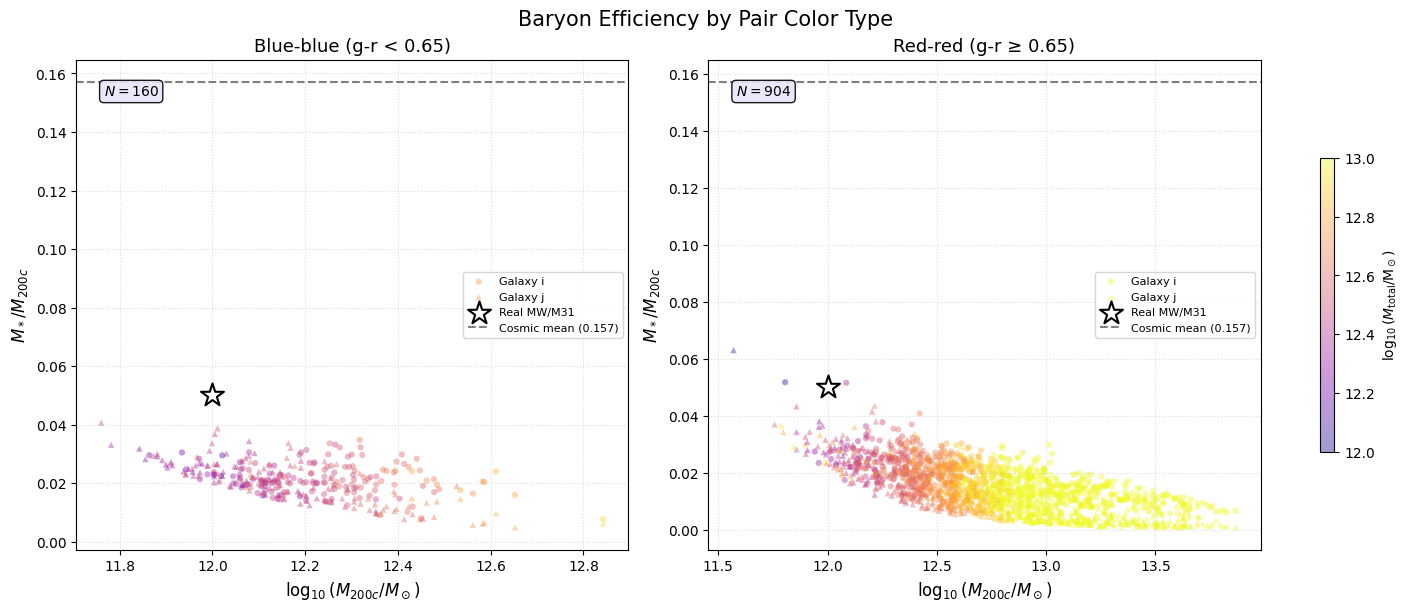

In [ ]:
# Baryon efficiency
def plot_baryon_efficiency(masks, legs, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
    cmap = plt.get_cmap('plasma')

    for col, (mask, leg) in enumerate(zip(masks, legs)):
        idx_i = pairs.i[keep][mask]
        idx_j = pairs.j[keep][mask]

        # Use primary (i) member as representative
        shmr_i = sample.mstar[idx_i] / sample.m200c[idx_i]
        shmr_j = sample.mstar[idx_j] / sample.m200c[idx_j]

        m_total_log = np.log10(sample.mtot[idx_i] + sample.mtot[idx_j])

        # Plot both members
        sc = axes[col].scatter(np.log10(sample.m200c[idx_i]), shmr_i,
                               c=m_total_log, s=20, alpha=0.4,
                               cmap=cmap, vmin=12.0, vmax=13.0,
                               edgecolors='none', label='Galaxy i')
        axes[col].scatter(np.log10(sample.m200c[idx_j]), shmr_j,
                          c=m_total_log, s=20, alpha=0.4,
                          cmap=cmap, vmin=12.0, vmax=13.0,
                          edgecolors='none', marker='^', label='Galaxy j')

        # Real LG reference MW/M31 masses ~ 0.05 at log M200c ~ 12.0
        axes[col].scatter(12.0, 0.05, color='white', marker='*',
                          s=300, edgecolors='black', linewidth=1.5,
                          label='Real MW/M31', zorder=5)

        # Cosmic mean baryon fraction
        axes[col].axhline(0.157, color='black', linestyle='--',
                          alpha=0.5, label='Cosmic mean (0.157)')

        axes[col].set_xlabel(r'$\log_{10}(M_{200c} / M_\odot)$', fontsize=12)
        axes[col].set_ylabel(r'$M_* / M_{200c}$', fontsize=12)
        axes[col].set_title(leg, fontsize=13)
        axes[col].legend(fontsize=8)
        axes[col].grid(True, linestyle=':', alpha=0.4)

        axes[col].text(0.05, 0.95, f"$N = {len(idx_i)}$",
                       transform=axes[col].transAxes, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.9))

    cb = fig.colorbar(sc, ax=axes, location='right',
                      label=r'$\log_{10}(M_{\mathrm{total}} / \mathrm{M}_\odot)$', shrink=0.6)

    plt.suptitle(title, fontsize=15)
    plt.show()

plot_baryon_efficiency(color_masks, color_legs, "Baryon Efficiency by Pair Color Type")

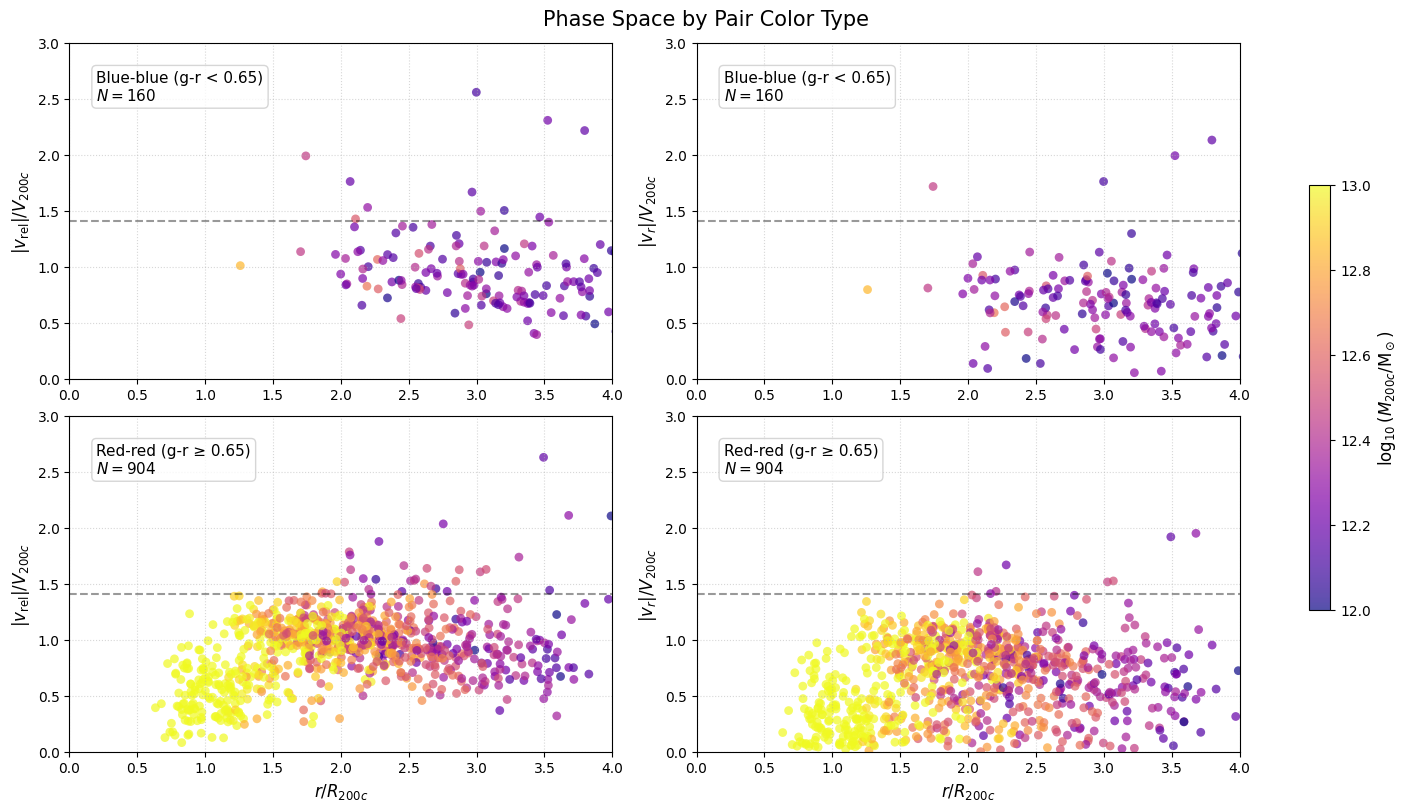

In [ ]:
# Phase space normalized separation and velocity by R200c and V200c
def plot_phase_space(masks, legs, title):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
    cmap = plt.get_cmap('plasma')

    for row, (mask, leg) in enumerate(zip(masks, legs)):
        idx_i = pairs.i[keep][mask]
        idx_j = pairs.j[keep][mask]

        # Normalize by R200c and V200c of primary (i) member
        r_norm = dist_kpc_final[mask] / sample.r200c[idx_i]
        v_rel = np.sqrt(v_r_final[mask]**2 + v_t_final[mask]**2)
        v_norm = v_rel / sample.v200c[idx_i]
        vr_norm = np.abs(v_r_final[mask]) / sample.v200c[idx_i]

        m_total_log = np.log10(sample.m200c[idx_i])

        # Left column: r/R200c vs |v_rel|/V200c
        sc0 = axes[row, 0].scatter(r_norm, v_norm, c=m_total_log, s=40, alpha=0.7,
                                    cmap=cmap, vmin=12.0, vmax=13.0, edgecolors='none')

        # Right column: r/R200c vs |v_r|/V200c
        sc1 = axes[row, 1].scatter(r_norm, vr_norm, c=m_total_log, s=40, alpha=0.7,
                                    cmap=cmap, vmin=12.0, vmax=13.0, edgecolors='none')

        # Escape velocity line
        for col in range(2):
            axes[row, col].axhline(y=np.sqrt(2), color='black', linestyle='--',
                                   alpha=0.4, label='Escape velocity')
            axes[row, col].text(0.05, 0.92, f"{leg}\n$N = {len(r_norm)}$",
                                transform=axes[row, col].transAxes,
                                verticalalignment='top', fontsize=11,
                                bbox=dict(boxstyle='round', facecolor='white',
                                          alpha=0.8, edgecolor='0.8'))
            axes[row, col].grid(True, linestyle=':', alpha=0.5)
            axes[row, col].set_xlim(0, 4)
            axes[row, col].set_ylim(0, 3)

    # Axis labels
    axes[0, 0].set_ylabel(r'$|v_{\mathrm{rel}}| / V_{200c}$', fontsize=12)
    axes[1, 0].set_ylabel(r'$|v_{\mathrm{rel}}| / V_{200c}$', fontsize=12)
    axes[0, 1].set_ylabel(r'$|v_{r}| / V_{200c}$', fontsize=12)
    axes[1, 1].set_ylabel(r'$|v_{r}| / V_{200c}$', fontsize=12)

    for col in range(2):
        axes[1, col].set_xlabel(r'$r / R_{200c}$', fontsize=12)

    cb = fig.colorbar(sc0, ax=axes, location='right', shrink=0.6)
    cb.set_label(r'$\log_{10}(M_{200c} / \mathrm{M}_\odot)$', size=12)

    plt.suptitle(title, fontsize=15)
    plt.show()

plot_phase_space(color_masks, color_legs, "Phase Space by Pair Color Type")

In [ ]:
from scipy.stats import ks_2samp

# Defining all quantities to compare between blue-blue and red-red
quantities = {
    'Separation [kpc]':         dist_kpc_final,
    'v_r [km/s]':               v_r_final,
    'v_t [km/s]':               v_t_final,
    'v_total [km/s]':           np.sqrt(v_r_final**2 + v_t_final**2),
    'Stellar mass i [log Msun]': np.log10(sample.mstar[pairs.i[keep]]),
    'Stellar mass j [log Msun]': np.log10(sample.mstar[pairs.j[keep]]),
    'Halo mass i [log Msun]':   np.log10(sample.m200c[pairs.i[keep]]),
    'Halo mass j [log Msun]':   np.log10(sample.m200c[pairs.j[keep]]),
    'Mass ratio stellar':        np.maximum(sample.mstar[pairs.i[keep]], sample.mstar[pairs.j[keep]]) / 
                                 np.minimum(sample.mstar[pairs.i[keep]], sample.mstar[pairs.j[keep]]),
    'Mass ratio halo':           np.maximum(sample.m200c[pairs.i[keep]], sample.m200c[pairs.j[keep]]) / 
                                 np.minimum(sample.m200c[pairs.i[keep]], sample.m200c[pairs.j[keep]]),
    'g-r i':                    g_r_1,
    'g-r j':                    g_r_2,
    '|v_r| x r [timing]':       np.abs(v_r_final) * dist_kpc_final,
    'r/R200c':                  dist_kpc_final / sample.r200c[pairs.i[keep]],
    'Force ratio':              f_ratios[keep],
}

# Run KS test for each quantity
print(f"{'Quantity':<30} {'KS stat':>10} {'p-value':>12} {'Significant':>12}")

ks_results = {}
for name, data in quantities.items():
    data_bb = data[blue_blue]
    data_rr = data[red_red]
    ks_stat, ks_pval = ks_2samp(data_bb, data_rr)
    ks_results[name] = (ks_stat, ks_pval)

for name, (stat, pval) in sorted(ks_results.items(), key=lambda x: x[1][1]):
    sig = "YES HIGHLY SIGNIFICANT" if pval < 0.001 else "YES MODERATELY SIGNIFICANT" if pval < 0.05 else "NO"
    print(f"{name:<30} {stat:>10.3f} {pval:>12.4f} {sig:>12}")

Quantity                          KS stat      p-value  Significant
g-r i                               1.000       0.0000 YES HIGHLY SIGNIFICANT
g-r j                               1.000       0.0000 YES HIGHLY SIGNIFICANT
Halo mass i [log Msun]              0.704       0.0000 YES HIGHLY SIGNIFICANT
Halo mass j [log Msun]              0.684       0.0000 YES HIGHLY SIGNIFICANT
Stellar mass i [log Msun]           0.629       0.0000 YES HIGHLY SIGNIFICANT
r/R200c                             0.572       0.0000 YES HIGHLY SIGNIFICANT
Stellar mass j [log Msun]           0.530       0.0000 YES HIGHLY SIGNIFICANT
v_total [km/s]                      0.438       0.0000 YES HIGHLY SIGNIFICANT
Mass ratio halo                     0.397       0.0000 YES HIGHLY SIGNIFICANT
v_r [km/s]                          0.390       0.0000 YES HIGHLY SIGNIFICANT
Mass ratio stellar                  0.348       0.0000 YES HIGHLY SIGNIFICANT
|v_r| x r [timing]                  0.311       0.0000 YES HIGHLY SIGNIFIC